## Brief analysis of OASIS Demographic and Clinical Data content

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel('oasis_cross-sectional-5708aa0a98d82080.xlsx')
df.head()

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


In [ ]:
df_size = df.shape
print(f'DF shape is {df_size}')

DF shape is (436, 12)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      436 non-null    object 
 1   M/F     436 non-null    object 
 2   Hand    436 non-null    object 
 3   Age     436 non-null    int64  
 4   Educ    235 non-null    float64
 5   SES     216 non-null    float64
 6   MMSE    235 non-null    float64
 7   CDR     235 non-null    float64
 8   eTIV    436 non-null    int64  
 9   nWBV    436 non-null    float64
 10  ASF     436 non-null    float64
 11  Delay   20 non-null     float64
dtypes: float64(7), int64(2), object(3)
memory usage: 41.0+ KB


In [ ]:
df.isna().sum()

,0
ID,0
M/F,0
Hand,0
Age,0
Educ,201
SES,220
MMSE,201
CDR,201
eTIV,0
nWBV,0


In [ ]:
df.corr(numeric_only=True)

,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
Age,1.000000,-0.207094,0.157806,-0.252123,0.299969,-0.140984,-0.874100,0.137514,0.220264
Educ,-0.207094,1.000000,-0.742361,0.297317,-0.254745,0.147271,0.194903,-0.126571,NaN
SES,0.157806,-0.742361,1.000000,-0.258882,0.198240,-0.184533,-0.118403,0.167573,NaN
MMSE,-0.252123,0.297317,-0.258882,1.000000,-0.750070,-0.005727,0.469599,0.014133,NaN
CDR,0.299969,-0.254745,0.198240,-0.750070,1.000000,0.105204,-0.501014,-0.114299,NaN
eTIV,-0.140984,0.147271,-0.184533,-0.005727,0.105204,1.000000,-0.009685,-0.975666,0.048510
nWBV,-0.874100,0.194903,-0.118403,0.469599,-0.501014,-0.009685,1.000000,0.013771,-0.193659
ASF,0.137514,-0.126571,0.167573,0.014133,-0.114299,-0.975666,0.013771,1.000000,-0.091070
Delay,0.220264,NaN,NaN,NaN,NaN,0.048510,-0.193659,-0.091070,1.000000


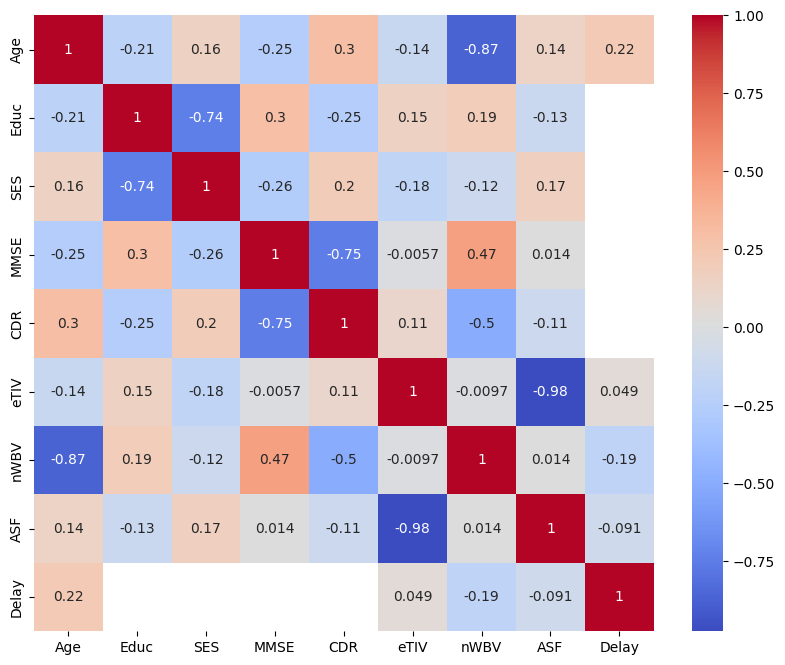

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

The heatmap above presents the correlation between the variables from the oasis_cross-sectional-5708aa0a98d82080 dataset; the most strong correlations lead to the next statements (hypothesis?):

**Note: A Pearson correlation value is considered actually strong when the value is superior or equal to 0.7 or 0.8; 0.5 is considered as moderate correlation**

- **Age and nWBV (Normalized whole brain volume) (-0.87)**: As a negative correlation, it signifies that as age increases, brain volumen decreases.

- **MMSE (Mini-mental state examination) and CDR (Clinical dementia rating) (- 0.75)**: The correlation indicates that lower MMSE scores are associated with higher dementia severity (CDR).

- **Education and SES (Socioeconomic status)(-0.74)**: The strong negative correlation reflects inverse coding of SES. Higher education is associated with higher socioeconomic status.

- **CDR (Clinical dementia rating) and nWBV (normalized whole brain volume)(-0.50)**: The moderate negative correlation indicates that higher CDR is associated with reduced normalized whole brain volume.

- **eTIV (estimated total intracranial volume) and ASF (Atlas scaling factor) (-0.98)**: This correlation represents a mathematical normalization process, hence it does not mean any valuable correlation for the analysis.



In [ ]:
df.head()

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


In [ ]:
df['Hand'].value_counts()

,count
Hand,
R,436


In [ ]:
df.drop(columns=['Hand'], inplace=True)

As seen by the output of the last cell, all values from column 'Hand' are 'R', thus, it has no great relevance in the analysis.

In [ ]:
df['M/F'].value_counts()

,count
M/F,
F,268
M,168


In [ ]:
#Convert categorical data to numerical to perform correlation between all variables

In [ ]:
gender_map = {'M': 0, 'F': 1}
df['M/F_num'] = df['M/F'].map(gender_map)
df.head()

,ID,M/F,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,M/F_num
0,OAS1_0001_MR1,F,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN,1
1,OAS1_0002_MR1,F,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN,1
2,OAS1_0003_MR1,F,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN,1
3,OAS1_0004_MR1,M,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN,0
4,OAS1_0005_MR1,M,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN,0


In [ ]:
df.drop(columns=['M/F'], inplace=True)

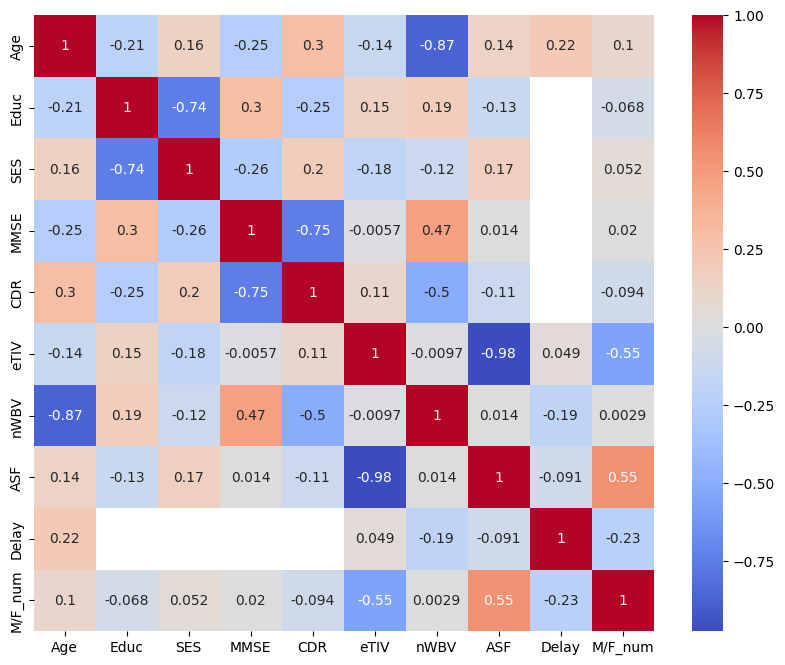

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

After adding the M/F_num column to the data, it can be seen to have a moderate correlation with eTIV. This means that, biologically, men tend to have a larger intracranial volumen than women.

However, the correlation between nWBV and M/F_num shows that, despite the inherent differences in eTIV between genders, the **normalized brain volume is nearly identical**.

Relevant variables
- Age
- MMSE
- CDR
- eTIV
- nWBV
- ASF

In [ ]:
df['Delay'].notna().sum()

np.int64(20)

In [ ]:
df.shape

(436, 11)

In [ ]:
df.isna().sum()

,0
ID,0
Age,0
Educ,201
SES,220
MMSE,201
CDR,201
eTIV,0
nWBV,0
ASF,0
Delay,416


Main variables distribution

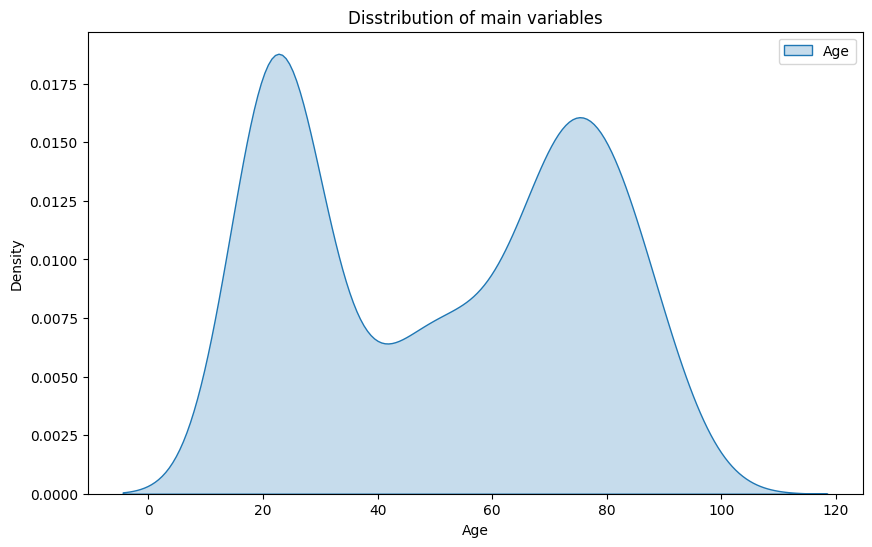

In [ ]:
plt.figure(figsize=(10,6))
#kernel density estimation
sns.kdeplot(data=df['Age'], label='Age', fill=True)
plt.title('Disstribution of main variables')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

<Axes: ylabel='Age'>

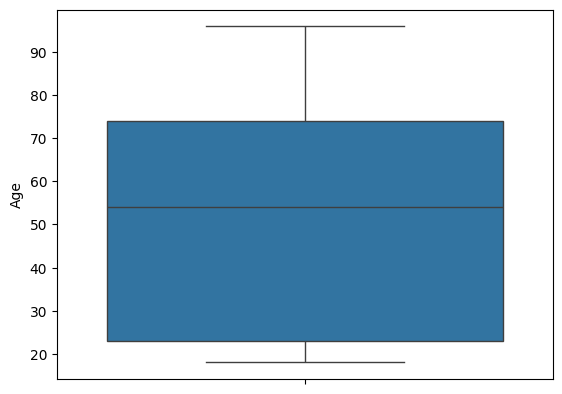

In [ ]:
sns.boxplot(data=df['Age'])

The last boxplot shows that half of the dataset has ages between 23 and 75.

While presenting no atypical data points (tyically represented as the so called 'whisquers').

<Axes: >

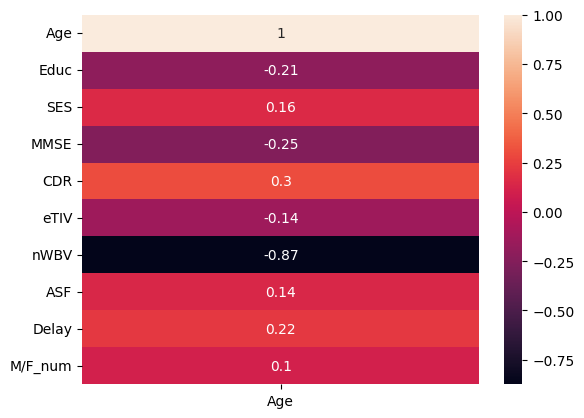

In [ ]:
corr = df.drop(columns=['ID']).corr()
corr_age = corr[['Age']]
sns.heatmap(corr_age, annot=True)


In order to understand how important delay is, we use a scatter plot to see how the other variables change

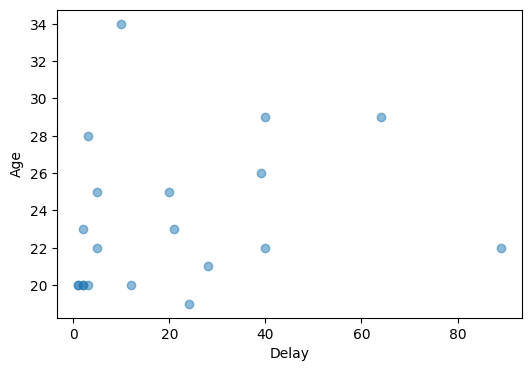

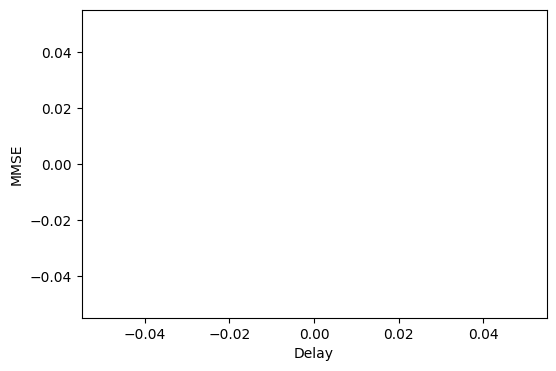

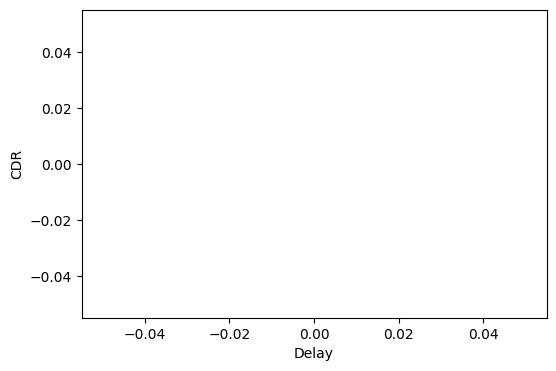

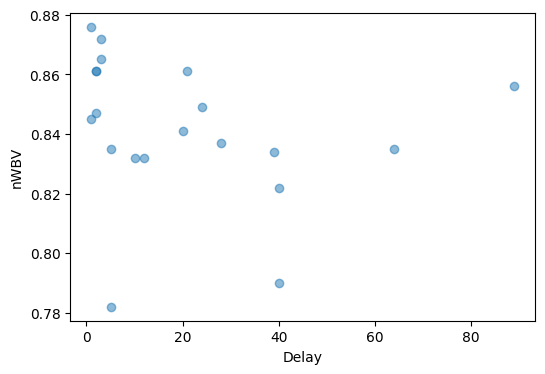

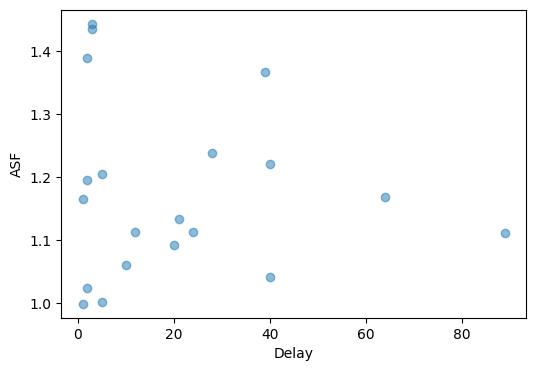

In [ ]:
features = ['Age', 'MMSE', 'CDR', 'nWBV', 'ASF']
for feat in features:
  plt.figure(figsize=(6, 4))
  plt.scatter(df['Delay'], df[feat], alpha=0.5)
  plt.xlabel('Delay')
  plt.ylabel(feat)
  plt.show()

The last scatter plots are used to confirm what the correlation matrix presented on delay and the other variables.
With such diverse data points (with nWBV and ASF), those two scatter plots indicate there is no actually important correlation between the two variables being compared.

Finding missing values

In [ ]:
df.head()

,ID,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,M/F_num
0,OAS1_0001_MR1,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN,1
1,OAS1_0002_MR1,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN,1
2,OAS1_0003_MR1,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN,1
3,OAS1_0004_MR1,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN,0
4,OAS1_0005_MR1,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN,0


In [ ]:
df_proposed = df.drop(columns=['Educ', 'SES', 'eTIV', 'ASF', 'Delay', 'M/F_num'])
df_proposed.head()

,ID,Age,MMSE,CDR,nWBV
0,OAS1_0001_MR1,74,29.0,0.0,0.743
1,OAS1_0002_MR1,55,29.0,0.0,0.810
2,OAS1_0003_MR1,73,27.0,0.5,0.708
3,OAS1_0004_MR1,28,NaN,NaN,0.803
4,OAS1_0005_MR1,18,NaN,NaN,0.848


In [ ]:
df_proposed.shape

(436, 5)

In [ ]:
#check for null in both columns (MMSE and CDR)
df_non_nulls = df_proposed[~pd.isnull(df_proposed[['MMSE', 'CDR']]).all(1)]
df_non_nulls.shape

(235, 5)

In [ ]:
#get the id's of null CDR registers
nulls = df_proposed[(df_proposed['MMSE'].isnull()) & (df_proposed['CDR'].isnull())]['ID']
nulls.to_list()
display(len(nulls))

201

At this point:
*   There are no patients with more than one session
*   There are no patients with null MMSE and CDR


